# Data cleaning

#### Normalise string values
- Standardised 'charity size' values (Large, Medium, Small, SMALL, small → Large, Medium, Small)
- Reduced unique values for this column from 5 to 3

#### Handle missing values
- Dropped high-missing columns (>70%) reducing the number of missing values from 1.46M to 81K
- Identified redundant column pairs using correlation value (>0.95)
- Protected important columns charity size, registration status, total gross income, total revenue
- Dropped redundant columns (fin report to and fin report from) reducing missing values to 65K
- Imputed remaining missing values using mode

#### Convert categorical columns to numerical
- Converted 19 boolean columns (Y/N) → binary (1/0)
- Converted 3 date columns → integer timestamps (days since epoch)
- Dropped 4 high-cardinality categorical columns (>10,000 unique values)
- Ordinal encoding: charity size (Small=1, Medium=2, Large=3)
- One-hot encoding: registration status (10 categories)

#### Generate class column
- Generated `is_se` class column based on earned revenue threshold (≥50%)
- Distribution: 10,201 SEs (19.1%), 43,084 non-SEs (80.9%)

# Analysis

In [7]:
import pandas as pd

df = pd.read_csv("data/ais23_cleaned.csv")

## What's a social enterprise?

Social enterprises (SEs):
- At least 50% revenue from earned income (goods and services)
- 10,201 charities qualify as SEs
- 19.1% of the whole sector

By size:
- Larger orgs are more likely to run as SEs
- There are many more small charities overall

In [8]:
from tabulate import tabulate

sizes = [1, 2, 3]
rows = []

for size in sizes:
    size_df = df[df['charity size'] == size]
    se_df = size_df[size_df['is_se'] == 1]
    se_pct = (len(se_df) / len(size_df) * 100) if len(size_df) > 0 else 0

    rows.append([
        size,
        f"{len(size_df):,}",
        f"{len(se_df):,}",
        f"{se_pct:.1f}%"
    ])

se_df = df[df['is_se'] == 1]
se_pct = (len(se_df) / len(df) * 100) if len(df) > 0 else 0

rows.append([
    'Total',
    f"{len(df):,}",
    f"{len(se_df):,}",
    f"{se_pct:.1f}%"
])

print(tabulate(
    rows,
    headers=['Size', 'Charities (SE and non-SE)', 'SEs', 'SE %'],
    tablefmt='fancy_grid',
    colalign=('left', 'right', 'right', 'right')
))

╒════════╤═════════════════════════════╤════════╤════════╕
│ Size   │   Charities (SE and non-SE) │    SEs │   SE % │
╞════════╪═════════════════════════════╪════════╪════════╡
│ 1      │                      39,537 │  6,716 │  17.0% │
├────────┼─────────────────────────────┼────────┼────────┤
│ 2      │                       8,121 │  1,961 │  24.1% │
├────────┼─────────────────────────────┼────────┼────────┤
│ 3      │                       5,627 │  1,524 │  27.1% │
├────────┼─────────────────────────────┼────────┼────────┤
│ Total  │                      53,285 │ 10,201 │  19.1% │
╘════════╧═════════════════════════════╧════════╧════════╛


## Income, expenses, and assets

Small charities:
- SEs bring in slightly more but spend more too
- Running lean with not much left over

Medium charities:
- SEs are spending alot: spending more than double what they are making

Large charities:
- SEs are nearly balanced in terms of outgoings vs income
- Efficient operations at scale

Overall patterns:
- SEs hold bigger assets than non-SEs
- They're also carrying more debt
- SEs borrow to reinvest and grow

Different strategies:
- SEs: Reinvesting money back into their work, higher risk
- Traditional charities: Playing it safe, lower risk

In [9]:
non_se_df = df[df['is_se'] == 0]

metrics = {
    'Avg total income ($)': 'total gross income',
    'Avg total expenses ($)': 'total expenses',
    'Avg assets ($)': 'total assets',
}

size_groups = [
    ('Small SE', se_df[se_df['charity size'] == 1]),
    ('Medium SE', se_df[se_df['charity size'] == 2]),
    ('Large SE', se_df[se_df['charity size'] == 3]),
    ('Overall SE', se_df),
    ('Small non-SE', non_se_df[non_se_df['charity size'] == 1]),
    ('Medium non-SE', non_se_df[non_se_df['charity size'] == 2]),
    ('Large non-SE', non_se_df[non_se_df['charity size'] == 3]),
    ('Overall non-SE', non_se_df),
]

rows = []

for group_label, group_df in size_groups:
    row = [group_label]
    for metric_label, col in metrics.items():
        value = group_df[col].sum() / len(group_df) if len(group_df) > 0 else 0
        row.append(f"${value:,.0f}")
    rows.append(row)
        
print(tabulate(
    rows,
    headers=['Group'] + list(metrics),
    tablefmt='fancy_grid',
    colalign=('left', 'right', 'right', 'right')
 ))

╒════════════════╤════════════════════════╤══════════════════════════╤══════════════════╕
│ Group          │   Avg total income ($) │   Avg total expenses ($) │   Avg assets ($) │
╞════════════════╪════════════════════════╪══════════════════════════╪══════════════════╡
│ Small SE       │               $119,112 │                 $121,967 │         $806,282 │
├────────────────┼────────────────────────┼──────────────────────────┼──────────────────┤
│ Medium SE      │             $1,358,451 │               $2,753,284 │       $3,450,704 │
├────────────────┼────────────────────────┼──────────────────────────┼──────────────────┤
│ Large SE       │            $34,680,341 │              $33,566,939 │      $67,970,430 │
├────────────────┼────────────────────────┼──────────────────────────┼──────────────────┤
│ Overall SE     │             $5,520,706 │               $5,624,383 │      $11,348,765 │
├────────────────┼────────────────────────┼──────────────────────────┼──────────────────┤
│ Small no

## Revenue sources

Goods & services:
- SEs dominate: 78-82% across all sizes
- Non-SEs: Only 7-19%

Government:
- SEs: 5-16% (not their main income)
- Non-SEs: 20-60% (major funding source)

Donations & Bequests:
- SEs: Only 1-7% (minimal reliance)
- Non-SEs: 9-47% (significant source)

Investments & other:
- Both groups: Around 1-4% each

Big picture:
- SEs: 78% commercial income = genuinely self-sustaining
- Non-SEs: 59% government + 10% donations = dependent funding
- Clear divide: SEs run like businesses

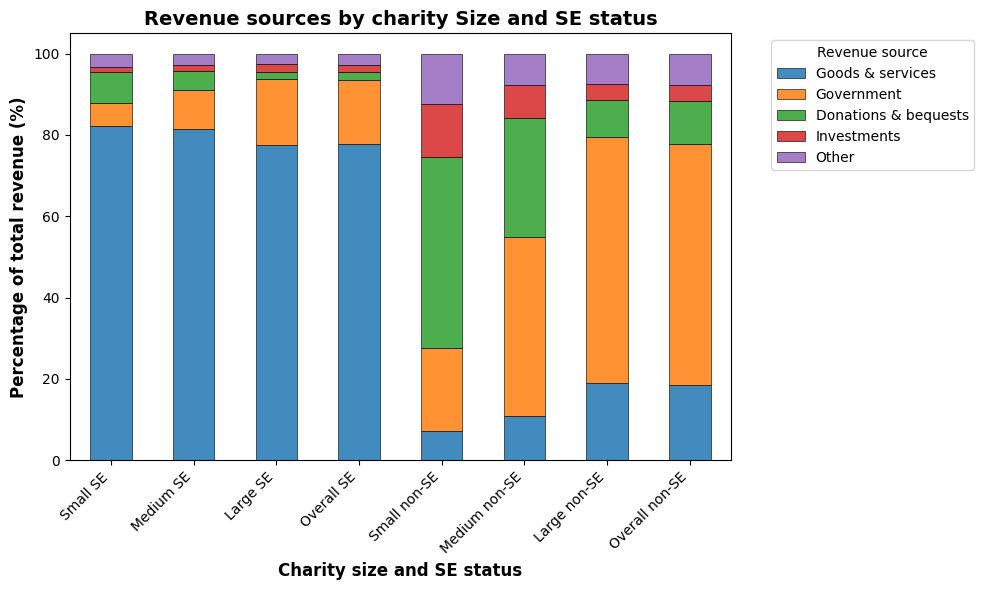

╒════════════════╤════════════════════╤══════════════╤════════════════════════╤═══════════════╤═════════╕
│ Group          │   Goods & services │   Government │   Donations & bequests │   Investments │ Other   │
╞════════════════╪════════════════════╪══════════════╪════════════════════════╪═══════════════╪═════════╡
│ Small SE       │              82.3% │         5.7% │                   7.4% │          1.4% │ 3.2%    │
├────────────────┼────────────────────┼──────────────┼────────────────────────┼───────────────┼─────────┤
│ Medium SE      │              81.5% │         9.7% │                   4.5% │          1.5% │ 2.8%    │
├────────────────┼────────────────────┼──────────────┼────────────────────────┼───────────────┼─────────┤
│ Large SE       │              77.6% │        16.1% │                   1.7% │          2.0% │ 2.7%    │
├────────────────┼────────────────────┼──────────────┼────────────────────────┼───────────────┼─────────┤
│ Overall SE     │              77.9% │       

In [10]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tabulate import tabulate

metrics = {
    'Goods & services': 'revenue from goods and services',
    'Government': 'revenue from government',
    'Donations & bequests': 'donations and bequests',
    'Investments': 'revenue from investments',
    'Other': 'all other revenue',
}

rows = []
chart_data = []

for group_label, group_df in size_groups:
    row = [group_label]
    chart_row = {'Group': group_label}
    for revenue_label, col in metrics.items():
        total_value = group_df[col].sum()
        total_revenue = group_df['total revenue'].sum()
        pct = (total_value / total_revenue * 100) if total_revenue > 0 else 0
        row.append(f"{pct:.1f}%")
        chart_row[revenue_label] = pct
    rows.append(row)
    chart_data.append(chart_row)

chart_df = pd.DataFrame(chart_data)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(metrics))

revenue_sources = list(metrics.keys())

chart_df.set_index('Group')[revenue_sources].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

ax.set_ylabel('Percentage of total revenue (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Charity size and SE status', fontsize=12, fontweight='bold')
ax.set_title('Revenue sources by charity Size and SE status',fontsize=14, fontweight='bold')
ax.legend(title='Revenue source', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(tabulate(
    rows,
    headers=['Group'] + list(metrics),
    tablefmt='fancy_grid',
    colalign=('left', 'right', 'right', 'right', 'right')
))

## Staffing

Small charities:
- Run almost entirely on volunteers
- More diverse staffing but lower overall capacity

Medium charities:
- Growing volunteer base as operations expand
- Similar paid staff, slightly better overall capacity

Large charities:
- Substantial paid workforce + large volunteer army
- Similar paid capacity but WAY more volunteers (453 vs 188)

Overall pattern:
- SEs: Lean on mix of volunteers (70 avg) and casual/part-time workers
- Non-SEs: More full-time paid staff (101 vs 15), but similar volunteer numbers
- SEs are lean operators scaling with flexible workforce
- Non-SEs have institutional staffing with fewer part-timers

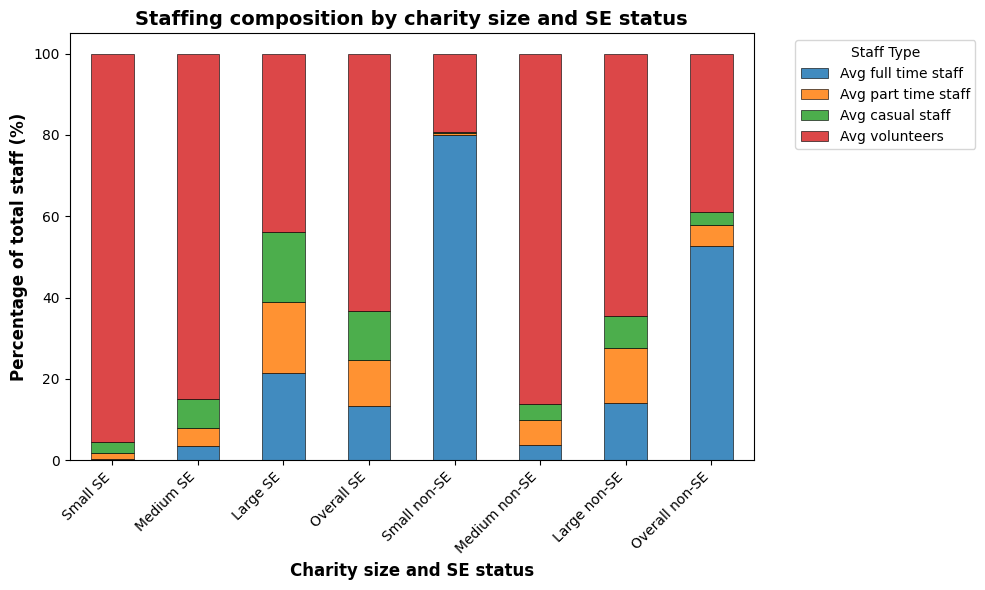

╒════════════════╤═══════════════════════╤═══════════════════════╤════════════════════╤══════════════════╤═════════════════╕
│ Group          │   Avg full time staff │   Avg part time staff │   Avg casual staff │   Avg volunteers │   Total Staff # │
╞════════════════╪═══════════════════════╪═══════════════════════╪════════════════════╪══════════════════╪═════════════════╡
│ Small SE       │                    0% │                    1% │                 3% │              95% │              36 │
├────────────────┼───────────────────────┼───────────────────────┼────────────────────┼──────────────────┼─────────────────┤
│ Medium SE      │                    3% │                    5% │                 7% │              85% │             110 │
├────────────────┼───────────────────────┼───────────────────────┼────────────────────┼──────────────────┼─────────────────┤
│ Large SE       │                   21% │                   18% │                17% │              44% │             431 │


In [ ]:
metrics = {
    'Avg full time staff': 'staff - full time',
    'Avg part time staff': 'staff - part time',
    'Avg casual staff': 'staff - casual',
    'Avg volunteers': 'staff - volunteers',
}

rows = []
chart_data = []


for group_label, group_df in size_groups:
    staff_counts = {}
    total_staff = 0

    for label, col in metrics.items():
        count = group_df[col].sum() / len(group_df) if len(group_df) > 0 else 0
        staff_counts[label] = count
        total_staff += count
    
    row = [group_label]
    chart_row = {'Group': group_label}
    for label in metrics.keys():
        pct = (staff_counts[label] / total_staff * 100) if total_staff > 0 else 0
        row.append(f"{pct:.0f}%")
        chart_row[label] = pct
    row.append(f"{int(total_staff)}")
    rows.append(row)
    chart_data.append(chart_row)

chart_df = pd.DataFrame(chart_data)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(metrics))

staff_types = list(metrics.keys())

chart_df.set_index('Group')[staff_types].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

ax.set_ylabel('Percentage of total staff (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Charity size and SE status', fontsize=12, fontweight='bold')
ax.set_title('Staffing composition by charity size and SE status', fontsize=14, fontweight='bold')
ax.legend(title='Staff Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(tabulate(
    rows,
    headers=['Group'] + list(metrics)+ ['Total staff #'],
    tablefmt='fancy_grid',
    colalign=('left', 'right', 'right', 'right', 'right')
))

## Feature importance to income (SEs)

Leverage and growth:
- Total liabilities account for 42% of income variance
- SEs with more debt generate significantly more revenue
- Interest expenses (10%) also matter, suggesting deliberate financing strategies
- SEs are borrowing strategically to invest and scale

Staffing capacity:
- Permanent workforce drives revenue more than flexible labour

Assets:
- Current assets matter more than non-current
- Liquid cash more important than buildings

In [ ]:
from sklearn.ensemble import RandomForestRegressor

df_se = df[df['is_se'] == 1]
            
X = df_se.drop([
    'is_se',
    'total gross income',
    'total revenue',
    'revenue from goods and services',
    'revenue from government',
    'donations and bequests',
    'revenue from investments',
    'all other revenue',
    'total expenses',
    'all other expenses',
    'employee expenses',
    'net surplus/deficit',
    'total comprehensive income'
], axis=1)
y = df_se['total gross income']

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_,
    'Importance %': model.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

rows = []
for idx, row in importance_df.head(10).iterrows():
    rows.append([
        row['Feature'],
        f"{row['Importance']:.4f}",
        f"{row['Importance %']:.2f}%"
    ])

print(tabulate(
    rows,
    headers=['Feature', 'Importance score', 'Percentage'],
    tablefmt='fancy_grid',
    colalign=('left', 'right', 'right')
))

╒══════════════════════════════════╤════════════════════╤══════════════╕
│ Feature                          │   Importance Score │   Percentage │
╞══════════════════════════════════╪════════════════════╪══════════════╡
│ total liabilities                │             0.4184 │       41.84% │
├──────────────────────────────────┼────────────────────┼──────────────┤
│ staff - full time                │             0.1731 │       17.31% │
├──────────────────────────────────┼────────────────────┼──────────────┤
│ interest expenses                │             0.1045 │       10.45% │
├──────────────────────────────────┼────────────────────┼──────────────┤
│ total current liabilities        │             0.0644 │        6.44% │
├──────────────────────────────────┼────────────────────┼──────────────┤
│ total current assets             │             0.0378 │        3.78% │
├──────────────────────────────────┼────────────────────┼──────────────┤
│ total full time equivalent staff │             0.